In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.colors import ListedColormap
colors = ["royalblue", "skyblue", "lightgreen", "gold", "tomato", "maroon", "navy"]
cmap = ListedColormap(colors)

import pickle

import scanpy as sc
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *

# Data

In [2]:
import sys
sys.path.append('../../ne_spectrum_scRNAseq')
from data_utils import load_human

In [3]:
root_path = '../../ne_spectrum_scRNAseq/data/'
X, labels, d = load_human(root_path=root_path)
X.shape, labels.shape

((20272, 50), (20272,))

In [8]:
n = len(X)

In [4]:
def convert(y):
    mapping = {'EB':0, 'Neuroectoderm':1, 'Neuroepithelium':2, 'Organoid-1M':3,
       'Organoid-2M':4, 'Organoid-4M':5, 'iPSCs':6}
    return [mapping[y[i]] for i in range(len(y))]
labels = convert(labels)
labels = np.array(labels)

In [12]:

with open('../results/brain/clusters.pkl', 'rb') as file:  
    clusters = pickle.load(file)

with open('../results/brain/ce_isomap_embeddings.pkl', 'rb') as file:  
    ce_1, ce_145  = pickle.load(file)
    
with open('../results/brain/ce_align_data.pkl', 'rb') as file:  
    alignment_idxs, distances = pickle.load(file)

In [21]:
n_clusters = len(np.unique(clusters))
n_clusters

13

In [11]:
embeddings = np.zeros((n,2))
for i in range(n_clusters):
    embeddings[clusters == i,:] = ce_1[clusters== i] - np.mean(ce_1[clusters== i], axis = 0)

In [17]:
embedding_sampled, clusters_sampled = embeddings[alignment_idxs,:], clusters[alignment_idxs]

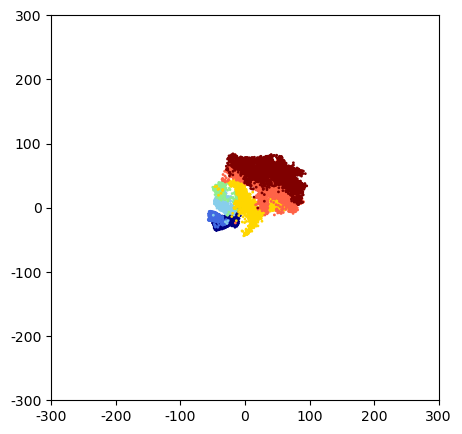

In [109]:
ce_1_, _ = procrustes(ce_145, ce_1)
plt.figure(figsize = [5,5])
plt.scatter(ce_1_[:,0], ce_1_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-325,275)
plt.ylim(-325,275)
plt.xticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.yticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.savefig('../figures/brain/alpha1.png', format='png', dpi=300, bbox_inches='tight')

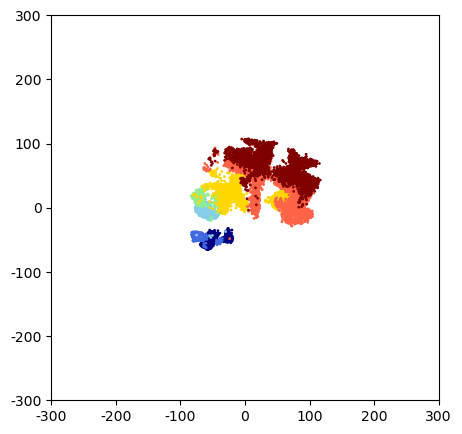

In [110]:

plt.figure(figsize = [5,5])
plt.scatter(ce_145[:,0], ce_145[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-325,275)
plt.ylim(-325,275)
plt.yticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.xticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.savefig('../figures/brain/alpha145.png', format='png', dpi=300, bbox_inches='tight')

In [72]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.75)
ce_175 = out.align_embedding(m = 50 )
ce_175 =  out.embed_points(embeddings,clusters)

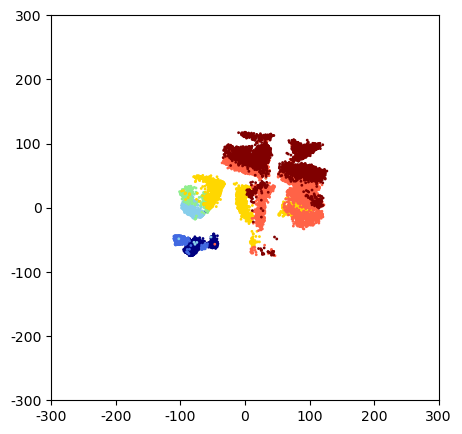

In [111]:
ce_175_, _ = procrustes(ce_145, ce_175)
plt.figure(figsize = [5,5])
plt.scatter(ce_175_[:,0], ce_175_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-325,275)
plt.ylim(-325,275)
plt.yticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.xticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))

plt.savefig('../figures/brain/alpha175.png', format='png', dpi=300, bbox_inches='tight')

In [74]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =2)
ce_2 = out.align_embedding(m = 50 )
ce_2 =  out.embed_points(embeddings,clusters)

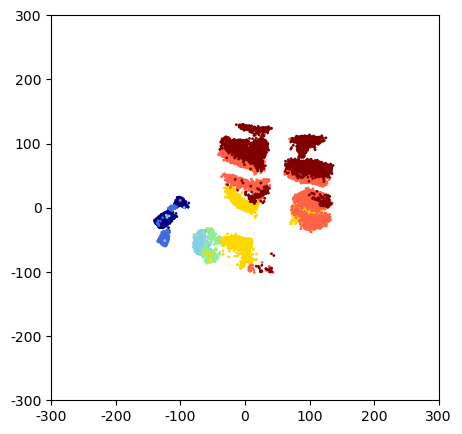

In [112]:
ce_2_, _ = procrustes(ce_145, ce_2)
plt.figure(figsize = [5,5])
plt.scatter(ce_2_[:,0], ce_2_[:,1], c = labels, cmap = cmap, s = 1)

plt.xlim(-325,275)
plt.ylim(-325,275)
plt.yticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.xticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.savefig('../figures/brain/alpha2.png', format='png', dpi=300, bbox_inches='tight')

In [68]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =3)
ce_3 = out.align_embedding(m = 50 )
ce_3 =  out.embed_points(embeddings,clusters)

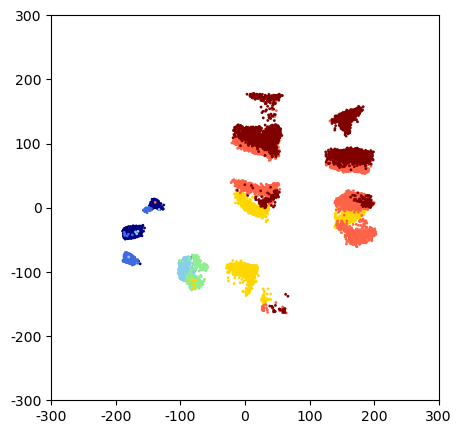

In [113]:
ce_3_, _ = procrustes(ce_145, ce_3)
plt.figure(figsize = [5,5])
plt.scatter(ce_3_[:,0], ce_3_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-350,250)
plt.ylim(-325,275)
plt.yticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.xticks(np.linspace(-350,250,7), labels = np.linspace(-300,300,7).astype(int))
plt.savefig('../figures/brain/alpha3.png', format='png', dpi=300, bbox_inches='tight')

In [77]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =4)
ce_4 = out.align_embedding(m = 50 )
ce_4 =  out.embed_points(embeddings,clusters)

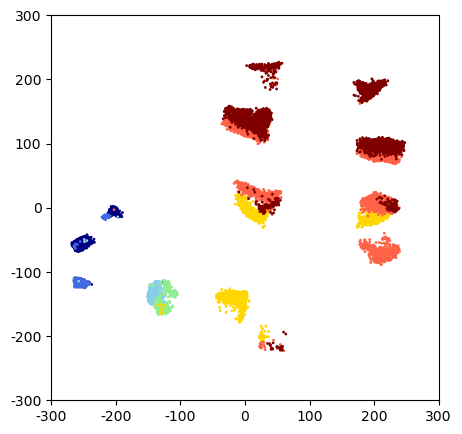

In [114]:
# ce_4_, _ = procrustes(ce_145, ce_4)
plt.figure(figsize = [5,5])
plt.scatter(ce_4_[:,0], ce_4_[:,1], c = labels, cmap = cmap, s = 1)
plt.xlim(-350,250)
plt.ylim(-325,275)
plt.yticks(np.linspace(-325,275,7), labels = np.linspace(-300,300,7).astype(int))
plt.xticks(np.linspace(-350,250,7), labels = np.linspace(-300,300,7).astype(int))
plt.savefig('../figures/brain/alpha4.png', format='png', dpi=300, bbox_inches='tight')

In [115]:
with open('../results/brain/alpha_exps.pkl', 'wb') as file:  
    pickle.dump([ce_1_, ce_145, ce_175_, ce_2_, ce_3_, ce_4_], file)

In [116]:

geodesic_distances = pd.read_csv("C:/Users/codae/OneDrive/Documents/clustering_embedding_data/bio_geodesic_5.csv")
geodesic_distances = squareform(geodesic_distances.to_numpy().flatten())
geodesic_distances.shape

data = pd.read_csv("C:/Users/codae/OneDrive/Documents/clustering_embedding_data/bio_data_5k.csv")
idxs = data['idxs'].to_numpy()

In [117]:
all_embs = [ce_1, ce_145, ce_175, ce_2, ce_3, ce_4]

In [118]:
orig_distances = geodesic_distances
for emb in all_embs:
    emb_distances =  squareform(pdist(emb[idxs]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[idxs])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[idxs])
    class_score = class_preservation(orig_distances, emb_distances, labels[idxs])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[idxs])
    recall_score = knn_recall(X[idxs], emb[idxs], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.76$ & $0.50$ & $0.36$ & $0.30$ & $0.65$ & $0.88$ & $0.37$ & $0.38$ & $0.20$ & $0.24$ & $0.95$

$0.80$ & $0.44$ & $0.38$ & $0.35$ & $0.68$ & $0.90$ & $0.23$ & $0.23$ & $0.20$ & $0.23$ & $0.93$

$0.82$ & $0.44$ & $0.39$ & $0.37$ & $0.68$ & $0.90$ & $0.30$ & $0.31$ & $0.20$ & $0.24$ & $0.94$

$0.82$ & $0.45$ & $0.40$ & $0.37$ & $0.67$ & $0.91$ & $0.41$ & $0.44$ & $0.19$ & $0.23$ & $0.93$

$0.82$ & $0.73$ & $0.45$ & $0.38$ & $0.65$ & $0.91$ & $0.99$ & $1.05$ & $0.21$ & $0.24$ & $0.94$

$0.82$ & $1.10$ & $0.49$ & $0.38$ & $0.62$ & $0.90$ & $1.61$ & $1.72$ & $0.22$ & $0.25$ & $0.94$

